# Exam 01: Visual Solution Notebook

**Course:** Machine Learning Theory  
**Institution:** Universidad Nacional de Colombia  
**Term:** 2026-1  
**Language:** English

This notebook is designed to be shown directly. It solves the entire exam with derivations, code, plots, and visual explanations in one place.


## Setup

The next cell contains all helper functions used in the notebook, including the MNIST loader and the kernel-regression utilities.


In [5]:
from __future__ import annotations

import gzip
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "exams" / "01" / "main.pdf").exists():
    ROOT = ROOT.parent
if not (ROOT / "exams" / "01" / "main.pdf").exists():
    raise FileNotFoundError("Could not locate exams/01/main.pdf from the current working directory.")

MNIST_DATA_DIR = ROOT / "data" / "raw" / "mnist"
MNIST_BASE_URLS = (
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
    "http://yann.lecun.com/exdb/mnist/",
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


def build_polynomial_design_matrix(x_samples: np.ndarray) -> np.ndarray:
    x_vector = np.asarray(x_samples, dtype=np.float64).reshape(-1)
    return np.column_stack((np.ones_like(x_vector), x_vector, x_vector ** 2))


def solve_regularized_least_squares(design_matrix: np.ndarray, targets: np.ndarray, lambda_reg: float) -> np.ndarray:
    phi = np.asarray(design_matrix, dtype=np.float64)
    t = np.asarray(targets, dtype=np.float64).reshape(-1)
    gram = phi.T @ phi
    rhs = phi.T @ t
    system = gram + lambda_reg * np.eye(phi.shape[1], dtype=np.float64)
    return np.linalg.solve(system, rhs)


def solve_kernelized_regularized_least_squares(design_matrix: np.ndarray, targets: np.ndarray, lambda_reg: float):
    phi = np.asarray(design_matrix, dtype=np.float64)
    t = np.asarray(targets, dtype=np.float64).reshape(-1)
    kernel_matrix = phi @ phi.T
    alpha = np.linalg.solve(kernel_matrix + lambda_reg * np.eye(phi.shape[0], dtype=np.float64), t)
    return alpha, phi.T @ alpha, kernel_matrix


def pairwise_squared_distances(x_matrix: np.ndarray) -> np.ndarray:
    x = np.asarray(x_matrix, dtype=np.float64)
    squared_norms = np.sum(x * x, axis=1, keepdims=True)
    distances = squared_norms + squared_norms.T - 2.0 * (x @ x.T)
    return np.maximum(distances, 0.0)


def rbf_kernel_matrix(x_matrix: np.ndarray, gamma: float) -> np.ndarray:
    return np.exp(-gamma * pairwise_squared_distances(x_matrix))


def cross_rbf_kernel_matrix(x_matrix: np.ndarray, y_matrix: np.ndarray, gamma: float) -> np.ndarray:
    x = np.asarray(x_matrix, dtype=np.float64)
    y = np.asarray(y_matrix, dtype=np.float64)
    x_norms = np.sum(x * x, axis=1, keepdims=True)
    y_norms = np.sum(y * y, axis=1, keepdims=True)
    distances = x_norms + y_norms.T - 2.0 * (x @ y.T)
    distances = np.maximum(distances, 0.0)
    return np.exp(-gamma * distances)


def biased_mmd2_from_gram(k_xx: np.ndarray, k_yy: np.ndarray, k_xy: np.ndarray) -> float:
    m = k_xx.shape[0]
    n = k_yy.shape[0]
    return float(np.sum(k_xx) / (m * m) + np.sum(k_yy) / (n * n) - 2.0 * np.sum(k_xy) / (m * n))


def median_heuristic_gamma(x_matrix: np.ndarray) -> float:
    distances = pairwise_squared_distances(x_matrix)
    nonzero = distances[distances > 0.0]
    return float(1.0 / np.median(nonzero))


def ensure_mnist_file(filename: str) -> Path:
    destination = MNIST_DATA_DIR / filename
    if destination.exists():
        return destination
    destination.parent.mkdir(parents=True, exist_ok=True)
    last_error = None
    for base_url in MNIST_BASE_URLS:
        try:
            with urllib.request.urlopen(base_url + filename, timeout=60) as response:
                with destination.open('wb') as output_handle:
                    shutil.copyfileobj(response, output_handle)
            return destination
        except Exception as exc:
            last_error = exc
            if destination.exists():
                destination.unlink()
    raise RuntimeError(f'Failed to download MNIST file {filename!r}.') from last_error


def load_mnist_images(path: Path) -> np.ndarray:
    with gzip.open(path, 'rb') as handle:
        magic = int.from_bytes(handle.read(4), 'big')
        if magic != 2051:
            raise ValueError(f'Unexpected image magic number {magic}.')
        count = int.from_bytes(handle.read(4), 'big')
        rows = int.from_bytes(handle.read(4), 'big')
        cols = int.from_bytes(handle.read(4), 'big')
        data = np.frombuffer(handle.read(), dtype=np.uint8)
    return data.reshape(count, rows * cols).astype(np.float64) / 255.0


def load_mnist_labels(path: Path) -> np.ndarray:
    with gzip.open(path, 'rb') as handle:
        magic = int.from_bytes(handle.read(4), 'big')
        if magic != 2049:
            raise ValueError(f'Unexpected label magic number {magic}.')
        count = int.from_bytes(handle.read(4), 'big')
        data = np.frombuffer(handle.read(), dtype=np.uint8)
    return data.reshape(count)


def load_mnist_training_set():
    images = load_mnist_images(ensure_mnist_file('train-images-idx3-ubyte.gz'))
    labels = load_mnist_labels(ensure_mnist_file('train-labels-idx1-ubyte.gz'))
    return images, labels


def select_balanced_mnist_subset(images: np.ndarray, labels: np.ndarray, samples_per_class: int, seed: int):
    rng = np.random.default_rng(seed)
    by_digit = {}
    for digit in range(10):
        indices = np.flatnonzero(labels == digit)
        chosen = rng.choice(indices, size=samples_per_class, replace=False)
        by_digit[digit] = images[np.sort(chosen)]
    return by_digit


def polynomial_regression_example(lambda_reg: float):
    x_samples = np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=np.float64)
    targets = 1.0 + 0.5 * x_samples + x_samples ** 2
    design_matrix = build_polynomial_design_matrix(x_samples)
    primal_weights = solve_regularized_least_squares(design_matrix, targets, lambda_reg=lambda_reg)
    alpha, dual_weights, kernel_matrix = solve_kernelized_regularized_least_squares(design_matrix, targets, lambda_reg=lambda_reg)
    predictions = design_matrix @ primal_weights
    return {
        'x_samples': x_samples,
        'targets': targets,
        'design_matrix': design_matrix,
        'estimated_weights': primal_weights,
        'predictions': predictions,
        'alpha': alpha,
        'kernel_matrix': kernel_matrix,
        'max_abs_primal_dual_difference': float(np.max(np.abs(primal_weights - dual_weights))),
    }


def mean_embedding_demo():
    x_samples = np.array([[0.0, 1.0], [1.0, 0.0], [2.0, 1.0]], dtype=np.float64)
    z_query = np.array([1.0, 2.0], dtype=np.float64)
    sample_mean = np.mean(x_samples, axis=0)
    linear_eval = float(sample_mean @ z_query)
    direct_linear_eval = float(np.mean(x_samples @ z_query))
    gamma = 0.5
    rbf_values = np.exp(-gamma * np.sum((x_samples - z_query) ** 2, axis=1))
    rbf_eval = float(np.mean(rbf_values))
    return {
        'samples': x_samples,
        'query': z_query,
        'linear_sample_mean': sample_mean,
        'linear_eval_via_mean': linear_eval,
        'linear_eval_direct_kernel_average': direct_linear_eval,
        'rbf_gamma': gamma,
        'rbf_values': rbf_values,
        'rbf_eval_at_query': rbf_eval,
    }


def mnist_mmd_full(samples_per_class: int, seed: int):
    images, labels = load_mnist_training_set()
    balanced = select_balanced_mnist_subset(images, labels, samples_per_class=samples_per_class, seed=seed)
    pooled = np.vstack([balanced[digit][:min(20, samples_per_class)] for digit in range(10)])
    gamma = median_heuristic_gamma(pooled)
    mmd_matrix = np.zeros((10, 10), dtype=np.float64)
    pair_scores = []
    for i in range(10):
        for j in range(i + 1, 10):
            k_xx = rbf_kernel_matrix(balanced[i], gamma)
            k_yy = rbf_kernel_matrix(balanced[j], gamma)
            k_xy = cross_rbf_kernel_matrix(balanced[i], balanced[j], gamma)
            score = biased_mmd2_from_gram(k_xx, k_yy, k_xy)
            mmd_matrix[i, j] = score
            mmd_matrix[j, i] = score
            pair_scores.append((i, j, score))
    pair_scores.sort(key=lambda item: item[2])
    return {
        'gamma': gamma,
        'mmd_matrix': mmd_matrix,
        'pair_scores': pair_scores,
        'balanced': balanced,
    }


def kernel_geometry_bundle(gamma: float, seed: int):
    images, labels = load_mnist_training_set()
    balanced = select_balanced_mnist_subset(images, labels, samples_per_class=5, seed=seed)
    x_small = np.vstack([balanced[0], balanced[1]])
    distances = pairwise_squared_distances(x_small)
    direct = np.sum((x_small[:, None, :] - x_small[None, :, :]) ** 2, axis=2)
    kernel = rbf_kernel_matrix(x_small, gamma=gamma)
    eigenvalues = np.linalg.eigvalsh(0.5 * (kernel + kernel.T))
    return {
        'x_small': x_small,
        'distances': distances,
        'direct': direct,
        'kernel': kernel,
        'eigenvalues': eigenvalues,
        'distance_error': float(np.max(np.abs(distances - direct))),
        'diag_error': float(np.max(np.abs(np.diag(kernel) - 1.0))),
        'symmetry_error': float(np.max(np.abs(kernel - kernel.T))),
    }


## 1. Regression in Feature Space and Kernel Formulation

Let

$$
\{(x_n,t_n)\}_{n=1}^N,
\qquad
x_n \in \mathbb{R}^P,
\qquad
t_n \in \mathbb{R},
\qquad
\phi : \mathbb{R}^P \to \mathcal{H}.
$$

The feature-space regression model is

$$
t_n = \langle w, \phi(x_n) \rangle_{\mathcal{H}} + \eta_n,
\qquad
\eta_n \sim \mathcal{N}(0,\sigma_\eta^2).
$$

The unknown parameter is $w \in \mathcal{H}$. The regularized least-squares problem is

$$
\widehat{w} = \arg\min_{w \in \mathcal{H}}
\left[
\frac{1}{2}\sum_{n=1}^N \bigl(t_n - \langle w, \phi(x_n) \rangle_{\mathcal{H}}\bigr)^2
+ \frac{\lambda}{2}\lVert w \rVert_{\mathcal{H}}^2
\right].
$$

For the polynomial feature map

$$
\phi(x) = \begin{bmatrix} 1 \\ x \\ x^2 \end{bmatrix},
$$

the design matrix is

$$
\Phi =
\begin{bmatrix}
1 & x_1 & x_1^2 \\
1 & x_2 & x_2^2 \\
\vdots & \vdots & \vdots \\
1 & x_N & x_N^2
\end{bmatrix}
\in \mathbb{R}^{N \times 3}.
$$

In matrix form, the estimator becomes

$$
\widehat{w} = (\Phi^{\top}\Phi + \lambda I)^{-1}\Phi^{\top} t.
$$

The figures below show the fitted polynomial, the recovered coefficients, the induced Gram matrix, and an animation of how the solution changes as the regularization level varies.


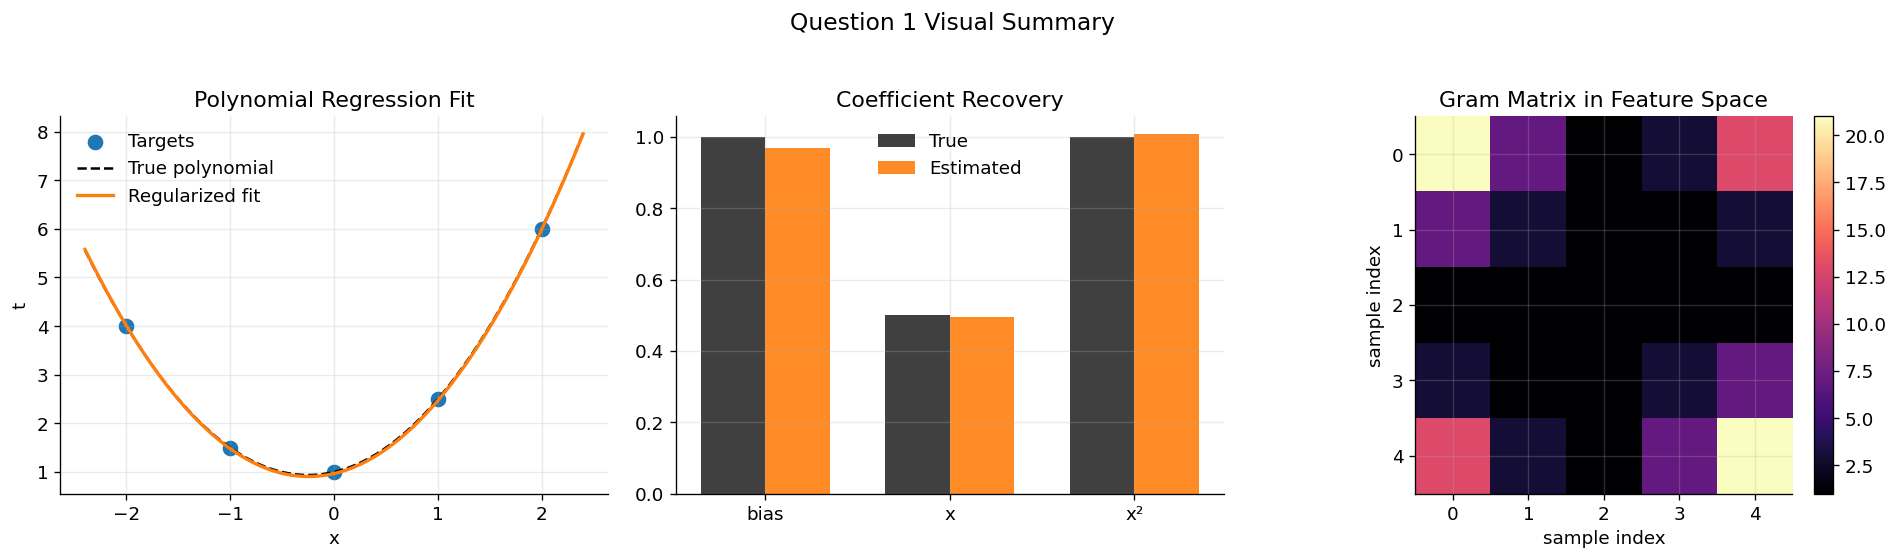

/home/mitin/code/ml-theory/.venv/lib/python3.14/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


Key takeaway: stronger regularization smooths the fit and pulls all coefficients toward zero, while the kernel and primal solutions remain numerically identical.


In [6]:
q1 = polynomial_regression_example(lambda_reg=0.1)
true_weights = np.array([1.0, 0.5, 1.0])
grid = np.linspace(-2.4, 2.4, 300)
phi_grid = build_polynomial_design_matrix(grid)
fit_grid = phi_grid @ q1['estimated_weights']
true_grid = 1.0 + 0.5 * grid + grid ** 2

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), dpi=120)

axes[0].scatter(q1['x_samples'], q1['targets'], s=70, color='tab:blue', label='Targets')
axes[0].plot(grid, true_grid, color='black', linestyle='--', linewidth=1.5, label='True polynomial')
axes[0].plot(grid, fit_grid, color='tab:orange', linewidth=2.0, label='Regularized fit')
axes[0].set_title('Polynomial Regression Fit')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].legend(frameon=False)

bar_x = np.arange(3)
width = 0.35
axes[1].bar(bar_x - width / 2, true_weights, width=width, color='black', alpha=0.75, label='True')
axes[1].bar(bar_x + width / 2, q1['estimated_weights'], width=width, color='tab:orange', alpha=0.9, label='Estimated')
axes[1].set_xticks(bar_x)
axes[1].set_xticklabels(['bias', 'x', 'x²'])
axes[1].set_title('Coefficient Recovery')
axes[1].legend(frameon=False)

im = axes[2].imshow(q1['kernel_matrix'], cmap='magma')
axes[2].set_title('Gram Matrix in Feature Space')
axes[2].set_xlabel('sample index')
axes[2].set_ylabel('sample index')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle('Question 1 Visual Summary', y=1.03, fontsize=14)
fig.tight_layout()
plt.show()

lambda_values = np.geomspace(1e-4, 3.0, 36)
prediction_frames = []
weight_frames = []
for lambda_value in lambda_values:
    weights = solve_regularized_least_squares(q1['design_matrix'], q1['targets'], float(lambda_value))
    prediction_frames.append(phi_grid @ weights)
    weight_frames.append(weights)
weight_frames = np.asarray(weight_frames)

fig_anim, (ax_fit, ax_coef) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=120)
ax_fit.scatter(q1['x_samples'], q1['targets'], s=60, color='tab:blue', label='Targets')
ax_fit.plot(grid, true_grid, color='black', linestyle='--', linewidth=1.4, label='True polynomial')
fit_line, = ax_fit.plot(grid, prediction_frames[0], color='tab:red', linewidth=2.2, label='Estimated fit')
ax_fit.set_xlim(grid.min(), grid.max())
ax_fit.set_ylim(min(q1['targets']) - 0.7, max(q1['targets']) + 0.7)
ax_fit.set_xlabel('x')
ax_fit.set_ylabel('t')
ax_fit.legend(frameon=False)

log_lambda = np.log10(lambda_values)
coef_labels = ['bias', 'x', 'x²']
coef_colors = ['tab:orange', 'tab:green', 'tab:purple']
coef_markers = []
for idx, (label, color) in enumerate(zip(coef_labels, coef_colors)):
    ax_coef.plot(log_lambda, weight_frames[:, idx], color=color, linewidth=2.0, label=label)
    marker, = ax_coef.plot([log_lambda[0]], [weight_frames[0, idx]], marker='o', color=color, markersize=7)
    coef_markers.append(marker)
ax_coef.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
ax_coef.set_xlabel('log10(lambda)')
ax_coef.set_ylabel('coefficient value')
ax_coef.legend(frameon=False)


def update_lambda(frame_index: int):
    fit_line.set_ydata(prediction_frames[frame_index])
    current_x = log_lambda[frame_index]
    for idx, marker in enumerate(coef_markers):
        marker.set_data([current_x], [weight_frames[frame_index, idx]])
    ax_fit.set_title(f'Fit for lambda = {lambda_values[frame_index]:.4f}')
    ax_coef.set_title('Coefficient shrinkage as lambda grows')
    return [fit_line, *coef_markers]

anim = FuncAnimation(fig_anim, update_lambda, frames=len(lambda_values), interval=220, repeat=True)
plt.close(fig_anim)
display(HTML(anim.to_jshtml()))

print('Key takeaway: stronger regularization smooths the fit and pulls all coefficients toward zero, while the kernel and primal solutions remain numerically identical.')


### SVD View and Kernel Trick

Let the thin singular value decomposition of the design matrix be

$$
\Phi = U_r \Sigma_r V_r^{\top},
$$

with rank $r$. Then

$$
\Phi^{\top}\Phi = V_r \Sigma_r^2 V_r^{\top},
\qquad
\Phi\Phi^{\top} = U_r \Sigma_r^2 U_r^{\top}.
$$

The second matrix is the Gram matrix

$$
K = \Phi\Phi^{\top} \in \mathbb{R}^{N \times N},
\qquad
K_{ij} = \langle \phi(x_i), \phi(x_j) \rangle_{\mathcal{H}}.
$$

Defining the dual coefficient vector

$$
\alpha = (K + \lambda I_N)^{-1} t,
$$

we obtain

$$
\widehat{w} = \Phi^{\top}\alpha,
\qquad
\widehat{f}(x) = \sum_{n=1}^N \alpha_n\,k(x_n,x).
$$

This is the kernel trick: prediction is written entirely in terms of kernel evaluations, without explicitly constructing the feature coordinates of a new sample.


## 2. RKHS, Mean Embeddings, and Discrepancy Between Distributions

Let $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ be a positive-definite kernel with associated RKHS $\mathcal{H}_k$. For a finite sample $\{x_n\}_{n=1}^N$, the empirical mean embedding is

$$
\widehat{\mu}_X = \frac{1}{N}\sum_{n=1}^N \phi(x_n)
= \frac{1}{N}\sum_{n=1}^N k(x_n,\cdot).
$$

At a query point $z \in \mathcal{X}$,

$$
\bigl\langle \widehat{\mu}_X, k(z,\cdot) \bigr\rangle_{\mathcal{H}_k}
= \frac{1}{N}\sum_{n=1}^N k(x_n,z).
$$

For two distributions $P$ and $Q$, the RKHS discrepancy is measured by the squared maximum mean discrepancy:

$$
\operatorname{MMD}^2(P,Q)
= \mathbb{E}[k(X,X')] + \mathbb{E}[k(Y,Y')] - 2\mathbb{E}[k(X,Y)].
$$

For finite samples $X_m = \{x_i\}_{i=1}^m$ and $Y_n = \{y_j\}_{j=1}^n$, define

$$
K_{XX} \in \mathbb{R}^{m \times m},
\qquad
K_{YY} \in \mathbb{R}^{n \times n},
\qquad
K_{XY} \in \mathbb{R}^{m \times n}.
$$

Then the biased empirical estimator is

$$
\widehat{\operatorname{MMD}}_{\mathrm{b}}^2
= \frac{1}{m^2}\mathbf{1}_m^{\top} K_{XX} \mathbf{1}_m
+ \frac{1}{n^2}\mathbf{1}_n^{\top} K_{YY} \mathbf{1}_n
- \frac{2}{mn}\mathbf{1}_m^{\top} K_{XY} \mathbf{1}_n.
$$

The outputs below make this visible through a geometric embedding demo, a full MNIST class-discrepancy heatmap, and representative digit samples from the closest and most separated pairs.


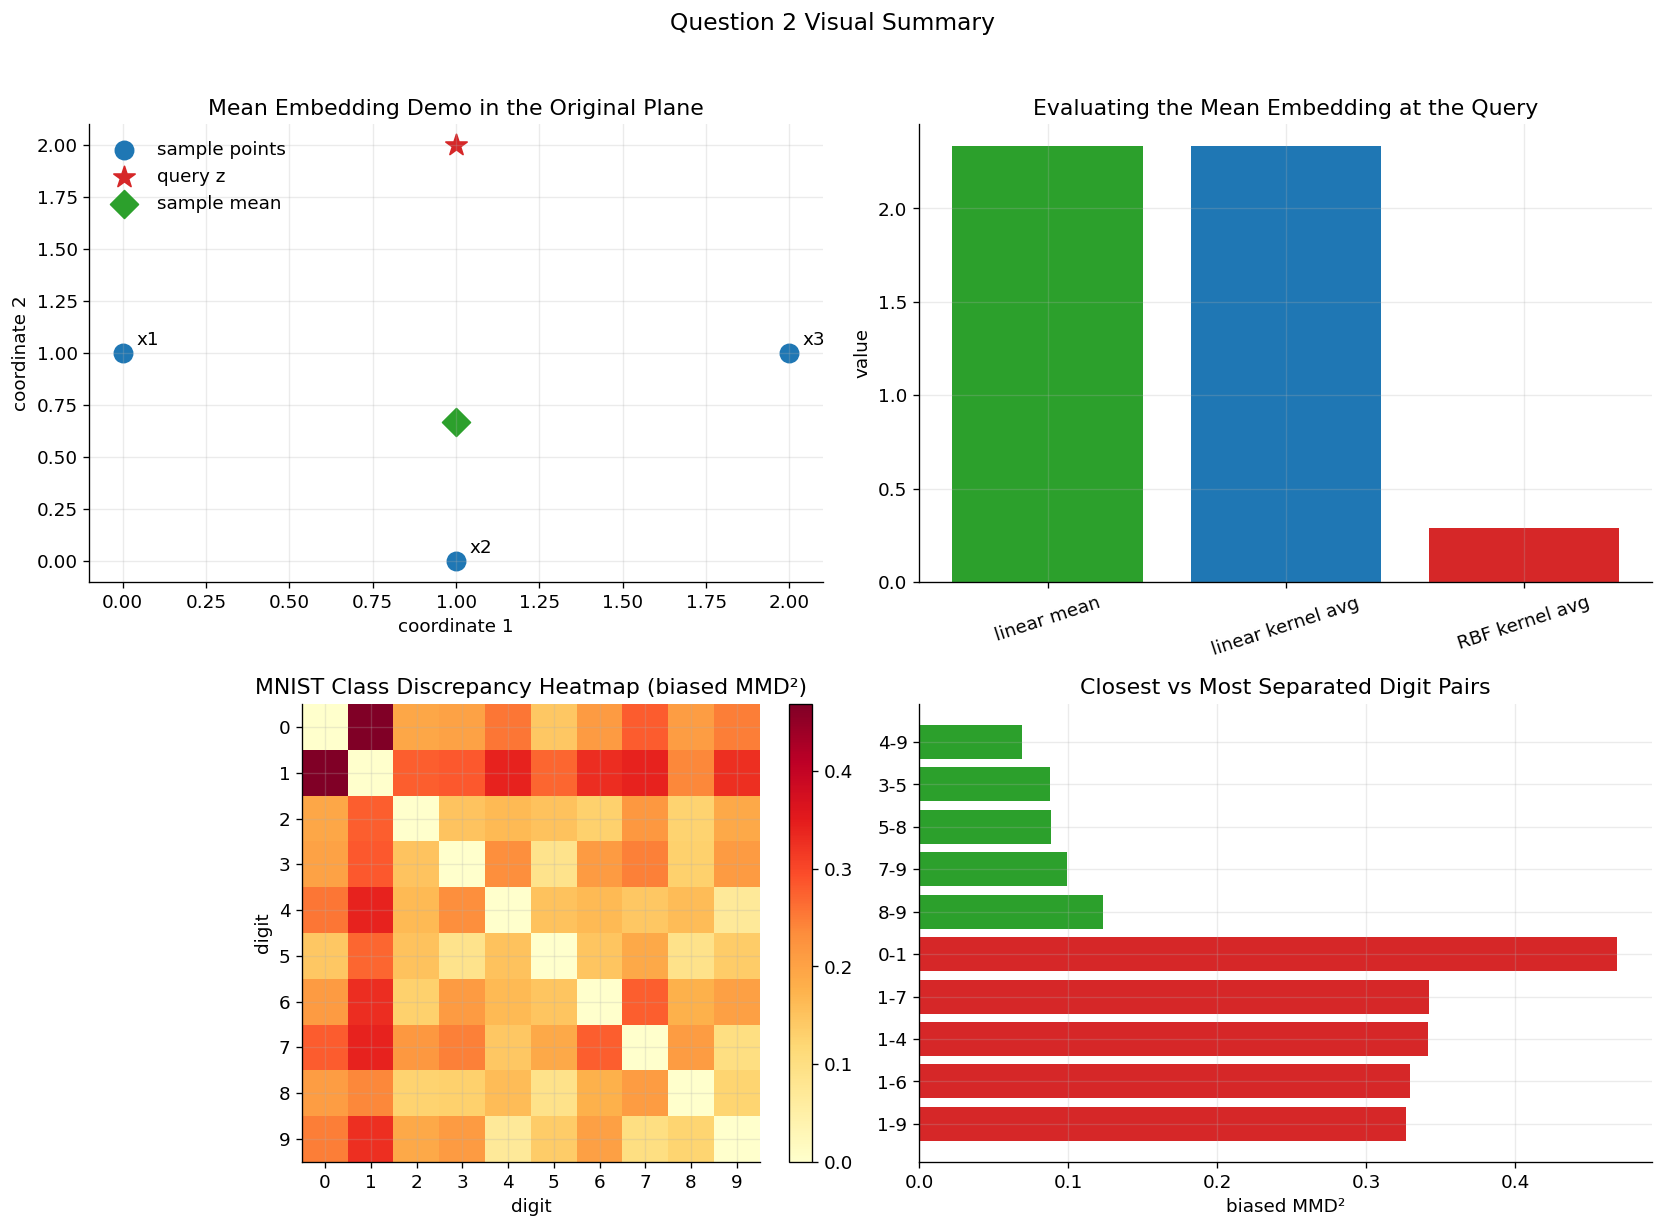

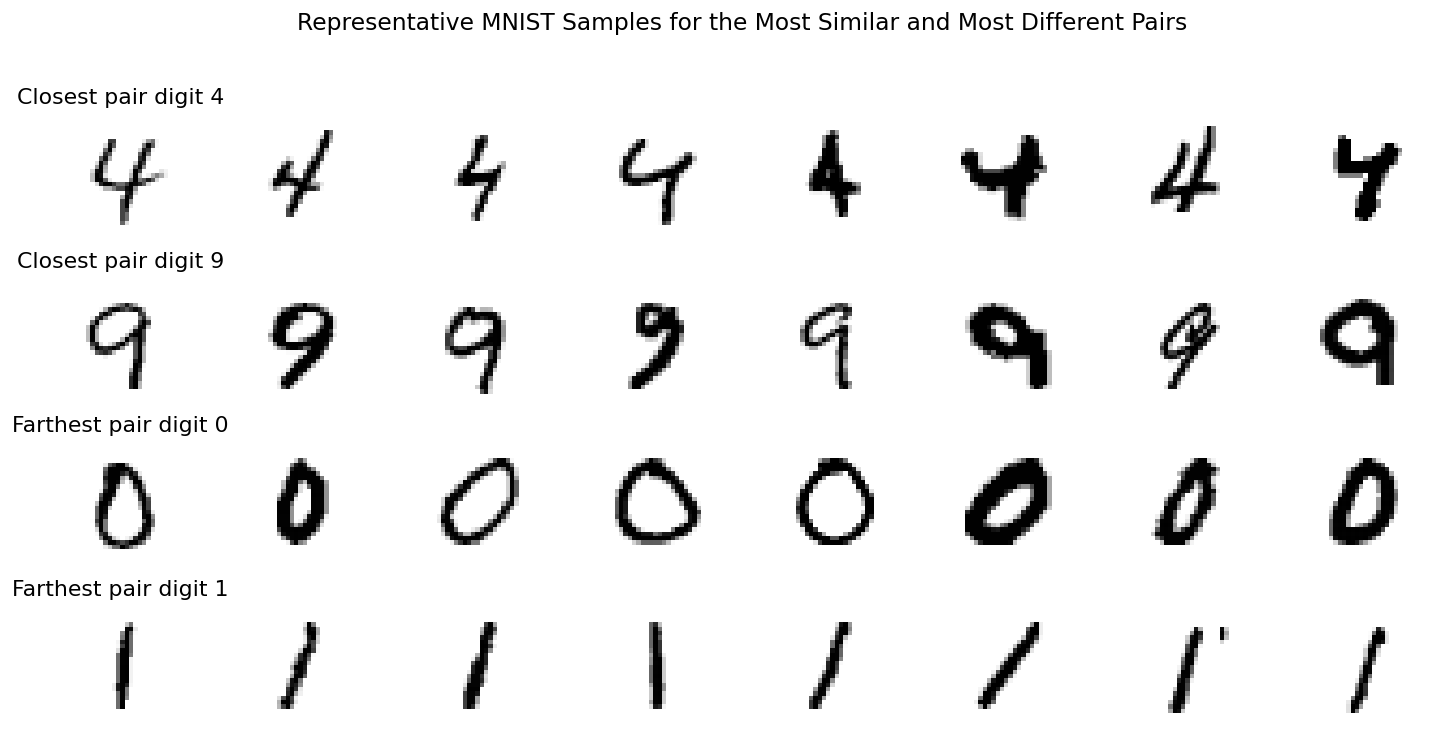

Closest pair: 4 vs 9 with MMD² = 0.0689
Most separated pair: 0 vs 1 with MMD² = 0.4687
Key takeaway: the heatmap exposes class-level structure immediately, while the digit strips show why some pairs look geometrically close and others do not.


In [7]:
embedding = mean_embedding_demo()
q2 = mnist_mmd_full(samples_per_class=100, seed=2026)
smallest = q2['pair_scores'][:5]
largest = q2['pair_scores'][-5:][::-1]
closest_pair = smallest[0][:2]
farthest_pair = largest[0][:2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

samples = embedding['samples']
query = embedding['query']
axes[0, 0].scatter(samples[:, 0], samples[:, 1], s=120, color='tab:blue', label='sample points')
for idx, point in enumerate(samples):
    axes[0, 0].annotate(f'x{idx+1}', point + np.array([0.04, 0.04]))
axes[0, 0].scatter([query[0]], [query[1]], s=180, color='tab:red', marker='*', label='query z')
axes[0, 0].scatter([embedding['linear_sample_mean'][0]], [embedding['linear_sample_mean'][1]], s=140, color='tab:green', marker='D', label='sample mean')
axes[0, 0].set_title('Mean Embedding Demo in the Original Plane')
axes[0, 0].set_xlabel('coordinate 1')
axes[0, 0].set_ylabel('coordinate 2')
axes[0, 0].legend(frameon=False, loc='upper left')

bar_labels = ['linear mean', 'linear kernel avg', 'RBF kernel avg']
bar_values = [embedding['linear_eval_via_mean'], embedding['linear_eval_direct_kernel_average'], embedding['rbf_eval_at_query']]
bar_colors = ['tab:green', 'tab:blue', 'tab:red']
axes[0, 1].bar(bar_labels, bar_values, color=bar_colors)
axes[0, 1].set_title('Evaluating the Mean Embedding at the Query')
axes[0, 1].set_ylabel('value')
axes[0, 1].tick_params(axis='x', rotation=18)

heat = axes[1, 0].imshow(q2['mmd_matrix'], cmap='YlOrRd')
axes[1, 0].set_title('MNIST Class Discrepancy Heatmap (biased MMD²)')
axes[1, 0].set_xlabel('digit')
axes[1, 0].set_ylabel('digit')
axes[1, 0].set_xticks(range(10))
axes[1, 0].set_yticks(range(10))
fig.colorbar(heat, ax=axes[1, 0], fraction=0.046, pad=0.04)

pair_labels = [f'{a}-{b}' for a, b, _ in smallest] + [f'{a}-{b}' for a, b, _ in largest]
pair_values = [score for _, _, score in smallest] + [score for _, _, score in largest]
pair_colors = ['tab:green'] * len(smallest) + ['tab:red'] * len(largest)
axes[1, 1].barh(pair_labels, pair_values, color=pair_colors)
axes[1, 1].set_title('Closest vs Most Separated Digit Pairs')
axes[1, 1].set_xlabel('biased MMD²')
axes[1, 1].invert_yaxis()

fig.suptitle('Question 2 Visual Summary', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

fig_digits, axes_digits = plt.subplots(4, 8, figsize=(12, 6), dpi=120)
for row, digit in enumerate(closest_pair):
    for col in range(4):
        axes_digits[row, col].imshow(q2['balanced'][digit][col].reshape(28, 28), cmap='gray_r')
        axes_digits[row, col].axis('off')
    axes_digits[row, 0].set_title(f'Closest pair digit {digit}')
for row, digit in enumerate(farthest_pair, start=2):
    for col in range(4):
        axes_digits[row, col].imshow(q2['balanced'][digit][col].reshape(28, 28), cmap='gray_r')
        axes_digits[row, col].axis('off')
    axes_digits[row, 0].set_title(f'Farthest pair digit {digit}')
for row in range(4):
    for col in range(4, 8):
        digit = closest_pair[row] if row < 2 else farthest_pair[row - 2]
        axes_digits[row, col].imshow(q2['balanced'][digit][col].reshape(28, 28), cmap='gray_r')
        axes_digits[row, col].axis('off')
fig_digits.suptitle('Representative MNIST Samples for the Most Similar and Most Different Pairs', y=1.02, fontsize=14)
fig_digits.tight_layout()
plt.show()

print(f"Closest pair: {closest_pair[0]} vs {closest_pair[1]} with MMD² = {smallest[0][2]:.4f}")
print(f"Most separated pair: {farthest_pair[0]} vs {farthest_pair[1]} with MMD² = {largest[0][2]:.4f}")
print('Key takeaway: the heatmap exposes class-level structure immediately, while the digit strips show why some pairs look geometrically close and others do not.')


## 3. Matrix Form of Kernels and Induced Geometry

Let $X \in \mathbb{R}^{N \times P}$ be the data matrix whose rows are the samples $x_1,\dots,x_N \in \mathbb{R}^P$. For two samples $x_i$ and $x_j$,

$$
\lVert x_i - x_j \rVert_2^2
= (x_i - x_j)^{\top}(x_i - x_j)
= x_i^{\top}x_i + x_j^{\top}x_j - 2x_i^{\top}x_j.
$$

If we define the vector of squared norms by

$$
s = \begin{bmatrix}
\lVert x_1 \rVert_2^2 \\
\vdots \\
\lVert x_N \rVert_2^2
\end{bmatrix}
\in \mathbb{R}^{N},
$$

then the full matrix of squared distances is

$$
D = s\mathbf{1}^{\top} + \mathbf{1}s^{\top} - 2XX^{\top}.
$$

For the Gaussian kernel matrix

$$
K_{ij} = \exp\bigl(-\gamma \lVert x_i - x_j \rVert_2^2\bigr),
$$

the diagonal entries satisfy

$$
K_{ii} = \exp(0) = 1,
$$

so every mapped sample has unit norm in feature space. Moreover, $K$ is symmetric and positive semidefinite, so it can be interpreted as a Gram matrix in the induced feature space.


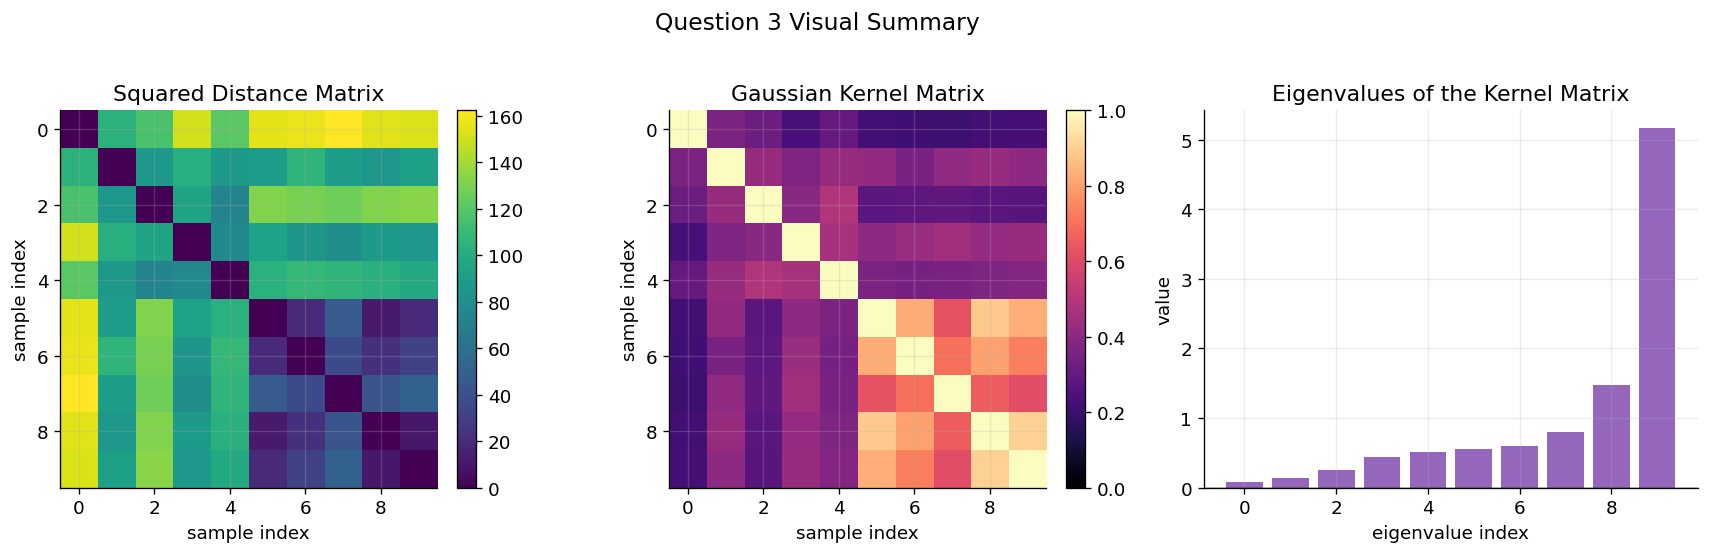

Max distance-formula error: 5.68e-14
Max kernel diagonal error from 1: 5.55e-16
Max symmetry error: 0.00e+00
Minimum eigenvalue: 0.0777
Key takeaway: the distance heatmap turns into a symmetric positive-semidefinite Gram matrix under the Gaussian kernel, with a constant diagonal exactly as the theory predicts.


In [8]:
geom = kernel_geometry_bundle(gamma=q2['gamma'], seed=2026)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)

dist_im = axes[0].imshow(geom['distances'], cmap='viridis')
axes[0].set_title('Squared Distance Matrix')
axes[0].set_xlabel('sample index')
axes[0].set_ylabel('sample index')
fig.colorbar(dist_im, ax=axes[0], fraction=0.046, pad=0.04)

ker_im = axes[1].imshow(geom['kernel'], cmap='magma', vmin=0.0, vmax=1.0)
axes[1].set_title('Gaussian Kernel Matrix')
axes[1].set_xlabel('sample index')
axes[1].set_ylabel('sample index')
fig.colorbar(ker_im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].bar(np.arange(len(geom['eigenvalues'])), geom['eigenvalues'], color='tab:purple')
axes[2].axhline(0.0, color='black', linewidth=0.8)
axes[2].set_title('Eigenvalues of the Kernel Matrix')
axes[2].set_xlabel('eigenvalue index')
axes[2].set_ylabel('value')

fig.suptitle('Question 3 Visual Summary', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

print(f"Max distance-formula error: {geom['distance_error']:.2e}")
print(f"Max kernel diagonal error from 1: {geom['diag_error']:.2e}")
print(f"Max symmetry error: {geom['symmetry_error']:.2e}")
print(f"Minimum eigenvalue: {geom['eigenvalues'].min():.4f}")
print('Key takeaway: the distance heatmap turns into a symmetric positive-semidefinite Gram matrix under the Gaussian kernel, with a constant diagonal exactly as the theory predicts.')
